In [1]:
library(tidyverse)
library(glue)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# Run mmseqs for every reference against the complete references
system("mkdir -p data-preparation/mmseqs-results")
system("mkdir -p data-preparation/tmp")
# Uncomment to run mmseqs2 searches
constant_sequence <- "data-preparation/references/MN090277.1.fasta"
library_references <- "data-preparation/references/sequences_20251001_HIV1.fa"

colnames_mmseqs <- c("query,target,fident,alnlen,mismatch,gapopen,qstart,qend,qlen,tstart,tend,tlen,evalue,bits")

basename <- "MN090277.1"
message(glue("Running mmseqs2 for {basename}\n"))
# system(glue("conda run -n mmseqs2-env mmseqs easy-search --max-seqs 5000 --max-seq-id 1.0 --search-type 3 --format-output {colnames_mmseqs} {constant_sequence} {library_references} data-preparation/mmseqs-results/{basename}_mmseqs.out.m8 data-preparation/tmp"))

Running mmseqs2 for MN090277.1



In [15]:
seqs <- c("AF443074.1
AY835773.1
AY835777.1
FJ670529.1
HM215250.1
K02013.1
K02083.1
KC156117.1
KU168259.1
MK457885.1
MK457977.1
MK458218.1
MK458244.1
MN043582.1
MN090187.1
MN090204.1
MN090211.1
MN090236.1
MN090271.1
MN090277.1
MN090294.1
MN090303.1
MN090316.1
MN090406.1
MN090437.1
MN090741.1
MN187301.1
MT191024.1
MT194498.1
MT929422.1
MW006075.1
MW063100.1
MW881692.1
MZ766594.1
PV207457.1
PV738262.1
U69584.1
U69588.1")

fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}

fident_window_to_float_range <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2]) * 100
  hi <- as.numeric(rng[, 3]) * 100
  sprintf("%.1f-%.1f", lo, hi)
}

mmseqs%>%
  filter(target %in% str_split(seqs, "\n")[[1]]) %>%
  mutate(
    fident_window_text = fident_window_to_digits(fident_window),
    id=paste0(target, "_", fident_window_text),
    ref = "MN090277.1",
    bin_range=fident_window_to_float_range(fident_window)
  ) %>%
  arrange(bin_range) %>%
  select(id, bin_range,target, ref)



id,bin_range,target,ref
<chr>,<chr>,<chr>,<chr>
HM215250.1_7474,73.5-74.0,HM215250.1,MN090277.1
MK457885.1_8080,79.5-80.0,MK457885.1,MN090277.1
PV207457.1_8080,80.0-80.5,PV207457.1,MN090277.1
MK458218.1_8081,80.5-81.0,MK458218.1,MN090277.1
MK458244.1_8182,81.0-81.5,MK458244.1,MN090277.1
MK457977.1_8282,81.5-82.0,MK457977.1,MN090277.1
MZ766594.1_8282,82.0-82.5,MZ766594.1,MN090277.1
MT194498.1_8283,82.5-83.0,MT194498.1,MN090277.1
AF443074.1_8384,83.0-83.5,AF443074.1,MN090277.1


In [3]:
# Combine mmseqs results
genome_size <- 9232
mmseqs <- read_tsv("./data-preparation/mmseqs-results/MN090277.1_mmseqs.out.m8", col_names = str_split(colnames_mmseqs, ",")[[1]]) %>%
    filter(alnlen/genome_size >= 0.6) %>%
    mutate(fident_window = cut(as.numeric(fident), breaks = seq(0.6, 1, by = 0.005), include.lowest = TRUE))

set.seed(42)
selected_references <- mmseqs %>%
    group_by(query, fident_window) %>%
    slice_max(order_by = bits, n=1, with_ties = FALSE) %>%
    ungroup()%>%
    mutate(is_selected = TRUE)%>%
    select(query,target, is_selected)

mmseqs <- merge(mmseqs, selected_references, by = c("query","target"), all.x=TRUE)%>%
  mutate(is_selected = ifelse(is.na(is_selected), FALSE, is_selected))


Rows: 3935 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): query, target
dbl (12): fident, alnlen, mismatch, gapopen, qstart, qend, qlen, tstart, ten...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


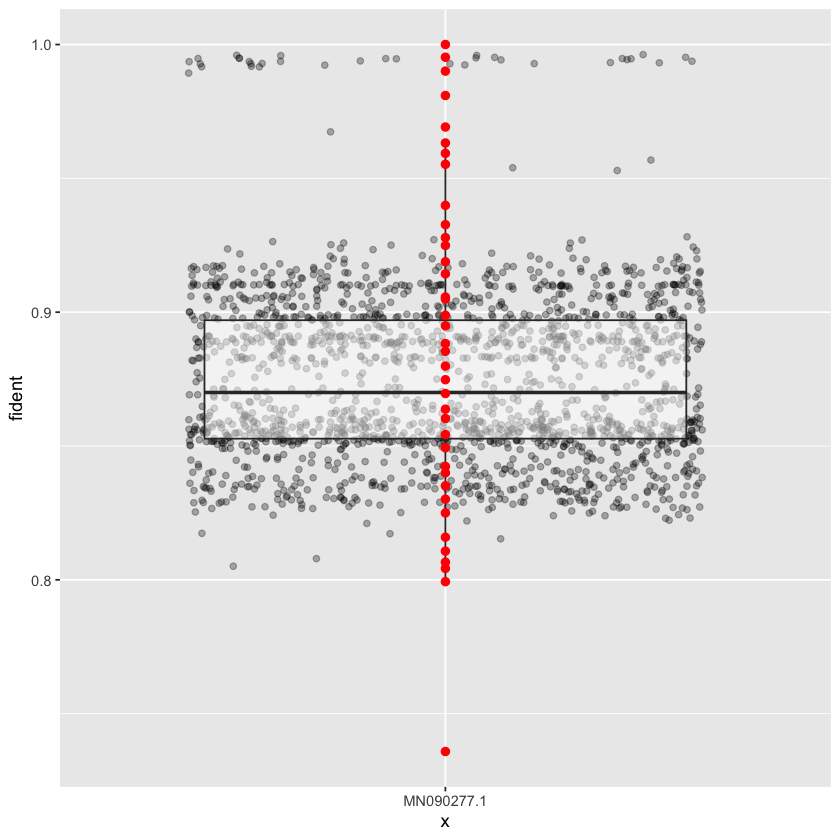

In [26]:
ggplot(mmseqs, aes(y= fident, x="MN090277.1")) +
    geom_jitter(data = subset(mmseqs, !is_selected), alpha = 0.3)+
    geom_boxplot(alpha=0.5, outlier.shape = NA) +
    geom_jitter(data = subset(mmseqs, is_selected), color = "red", size = 2, width = 0)

In [44]:
fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}
export <- mmseqs %>%
    mutate(fident_window = fident_window_to_digits(fident_window))%>%
    filter(is_selected) %>%
    mutate(id=paste0(target, "_", fident_window), ref = "MN090277.1") %>%
    select(id,target,ref)

write_tsv(export , "./data-preparation/selected_references.tsv")

In [43]:
lapply(export$target, function(acc) {
    system(glue("seqkit grep -r -p {acc} {library_references}  > data-preparation/references/{acc}.fasta"))
})

[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

[[9]]
[1] 0

[[10]]
[1] 0

[[11]]
[1] 0

[[12]]
[1] 0

[[13]]
[1] 0

[[14]]
[1] 0

[[15]]
[1] 0

[[16]]
[1] 0

[[17]]
[1] 0

[[18]]
[1] 0

[[19]]
[1] 0

[[20]]
[1] 0

[[21]]
[1] 0

[[22]]
[1] 0

[[23]]
[1] 0

[[24]]
[1] 0

[[25]]
[1] 0

[[26]]
[1] 0

[[27]]
[1] 0

[[28]]
[1] 0

[[29]]
[1] 0

[[30]]
[1] 0

[[31]]
[1] 0

[[32]]
[1] 0

[[33]]
[1] 0

[[34]]
[1] 0

[[35]]
[1] 0

[[36]]
[1] 0

[[37]]
[1] 0

[[38]]
[1] 0

In [ ]:
samplesheet <- export %>%
    mutate(sample = gsub("_",".",id),
        fastq_1 = glue("data-preparation/simulated-reads/{id}_R1.fastq.gz"),
        fastq_2 = glue("data-preparation/simulated-reads/{id}_R2.fastq.gz")
    )%>%
    select(sample, fastq_1, fastq_2)

write_csv(samplesheet, "./samplesheet.csv")